In [12]:
!pip install protobuf==3.20.3

*Requirement*

In [13]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
import gc

# Load data
Lấy dữ liệu từ nhánh data, dữ liệu đã được làm sạch và chuẩn hóa nên chỉ thực hiện upload, nếu cần xử lí thêm sẽ bổ sung sau

In [20]:
IMG_SIZE = 150
BATCH_SIZE = 32
EPOCHS = 20
KAGGLE_PATH = '/kaggle/input/processed-img-2/processed/train'
# Đường dẫn local (để code không lỗi khi bạn paste lại vào VS Code)
LOCAL_PATH = os.path.join('..', 'data', 'processed', 'train')

if os.path.exists(KAGGLE_PATH):
    print("MÔI TRƯỜNG: KAGGLE GPU")
    dataset_path = KAGGLE_PATH
elif os.path.exists(LOCAL_PATH):
    print("MÔI TRƯỜNG: LOCAL PC")
    dataset_path = LOCAL_PATH
else:
    raise FileNotFoundError("❌ Không tìm thấy dữ liệu! Hãy Add Data trên Kaggle.")

print(f"Đang đọc dữ liệu từ: {dataset_path}")
data = []
labels = []
categories = ['NORMAL', 'PNEUMONIA']

for category in categories:
    path = os.path.join(dataset_path, category)
    class_num = categories.index(category)
    try:
        files = os.listdir(path)
        if 'kaggle' not in dataset_path.lower():
            files = files[:100]
            
        for img_name in files:
            try:
                img_path = os.path.join(path, img_name)
                img_array = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if img_array is not None:
                    resized_arr = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
                    data.append(resized_arr)
                    labels.append(class_num)
            except Exception as e:
                pass
    except Exception as e:
        print(f"Lỗi đọc folder {category}: {e}")

print(f"Đã load xong: {len(data)} ảnh.")

MÔI TRƯỜNG: KAGGLE GPU
Đang đọc dữ liệu từ: /kaggle/input/processed-img-2/processed/train
Đã load xong: 17601 ảnh.


In [21]:
X = np.array(data)
y = np.array(labels)

# Giải phóng RAM
del data
del labels
gc.collect()

# Chuẩn hóa 0-255 -> 0-1
X = X / 255.0
X = X.reshape(-1, IMG_SIZE, IMG_SIZE, 1)

# Chia tập Train/Val (80/20)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"📊 Train set: {X_train.shape}")
print(f"📊 Val set:   {X_val.shape}")

📊 Train set: (14080, 150, 150, 1)
📊 Val set:   (3521, 150, 150, 1)


# CNN 

Xây dựng mô hình

In [22]:
model = Sequential()

model.add(Input(shape=(IMG_SIZE, IMG_SIZE, 1)))

# Lớp 1
model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

# Lớp 2
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

# Lớp 3
model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))

# Lớp Phẳng
model.add(Conv2D(256, (3,3), activation='relu', padding='same'))
model.add(BatchNormalization())
model.add(MaxPooling2D(2,2))
# Lớp Neuron
model.add(Flatten())
model.add(Dense(512, activation='relu'))
model.add(Dropout(0.5)) # Tránh Overfitting
model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 150, 150, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 150, 150, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 75, 75, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 75, 75, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 75, 75, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 37, 37, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 37, 37, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 37, 37, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 18, 18, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 18, 18, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │    10,617,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,007,617 (41.99 MB)

 Trainable params: 11,006,657 (41.99 MB)

 Non-trainable params: 960 (3.75 KB)

In [23]:
callbacks = [
    EarlyStopping(patience=5, restore_best_weights=True, monitor='val_loss'),
    ModelCheckpoint('cnn_pneumonia_model.keras', save_best_only=True, monitor='val_accuracy'),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

print("Bắt đầu train")
history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    callbacks=callbacks
)

Bắt đầu train
Epoch 1/20


I0000 00:00:1765099167.518598     116 service.cc:148] XLA service 0x7eba94006030 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1765099167.519267     116 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1765099167.519289     116 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1765099168.037074     116 cuda_dnn.cc:529] Loaded cuDNN version 90300


  3/440 ━━━━━━━━━━━━━━━━━━━━ 18s 42ms/step - accuracy: 0.5920 - loss: 2.8814   

I0000 00:00:1765099173.258849     116 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


440/440 ━━━━━━━━━━━━━━━━━━━━ 28s 40ms/step - accuracy: 0.9004 - loss: 1.4624 - val_accuracy: 0.5907 - val_loss: 17.6963 - learning_rate: 0.0010
Epoch 2/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.9597 - loss: 0.1117 - val_accuracy: 0.9636 - val_loss: 0.0922 - learning_rate: 0.0010
Epoch 3/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 16s 35ms/step - accuracy: 0.9730 - loss: 0.0792 - val_accuracy: 0.9719 - val_loss: 0.0703 - learning_rate: 0.0010
Epoch 4/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 15s 34ms/step - accuracy: 0.9746 - loss: 0.0776 - val_accuracy: 0.9571 - val_loss: 0.1284 - learning_rate: 0.0010
Epoch 5/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 0.9828 - loss: 0.0526 - val_accuracy: 0.9253 - val_loss: 0.3140 - learning_rate: 0.0010
Epoch 6/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 16s 37ms/step - accuracy: 0.9782 - loss: 0.0648 - val_accuracy: 0.9810 - val_loss: 0.0468 - learning_rate: 0.0010
Epoch 7/20
440/440 ━━━━━━━━━━━━━━━━━━━━ 15s 34ms/step - accuracy: 0.9870 - loss: 0.035

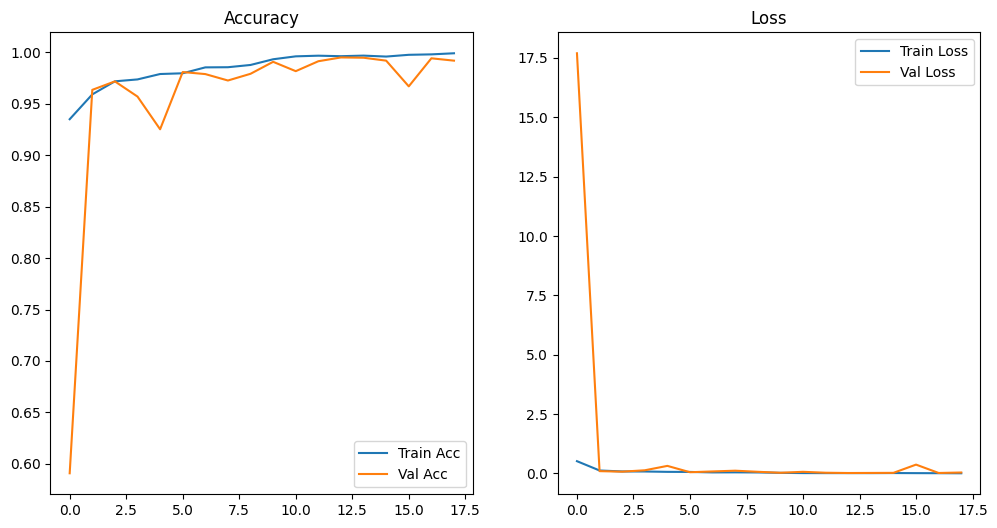

File model đã được lưu: cnn_pneumonia_model.keras


In [24]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Acc')
plt.plot(val_acc, label='Val Acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()

print("File model đã được lưu: cnn_pneumonia_model.keras")